In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ensure necessary folders exist
os.makedirs('data', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)

In [3]:
# Generate a realistic 365-day Stock Market dataset
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

In [4]:
# Simulate daily stock price with a random walk and moving averages
daily_returns = np.random.normal(0.0008, 0.015, 365)
price = 150 * np.cumprod(1 + daily_returns)
volume = np.random.randint(1000000, 5000000, 365)

In [5]:
# Create DataFrame
df_stock = pd.DataFrame({
    'Date': dates,
    'Close_Price': np.round(price, 2),
    'Daily_Return_Pct': np.round(daily_returns * 100, 2),
    'Volume': volume
})

In [6]:
# Calculate 20-Day and 50-Day Moving Averages
df_stock['MA_20'] = np.round(df_stock['Close_Price'].rolling(window=20).mean(), 2)
df_stock['MA_50'] = np.round(df_stock['Close_Price'].rolling(window=50).mean(), 2)

In [7]:
# Save as CSV
df_stock.to_csv('data/stock_market_data.csv', index=False)
print("stock_market_data.csv successfully created in data/ folder!")

stock_market_data.csv successfully created in data/ folder!


In [8]:
# Display basic dataset information
print("\nDataset Shape:", df_stock.shape)
display(df_stock.head(10))


Dataset Shape: (365, 6)


,Date,Close_Price,Daily_Return_Pct,Volume,MA_20,MA_50
0,2025-01-01,151.24,0.83,4388532,NaN,NaN
1,2025-01-02,151.04,-0.13,2425541,NaN,NaN
2,2025-01-03,152.63,1.05,2509433,NaN,NaN
3,2025-01-04,156.24,2.36,2871403,NaN,NaN
4,2025-01-05,155.82,-0.27,2553068,NaN,NaN
5,2025-01-06,155.40,-0.27,1653983,NaN,NaN
6,2025-01-07,159.20,2.45,2464492,NaN,NaN
7,2025-01-08,161.16,1.23,1821052,NaN,NaN
8,2025-01-09,160.16,-0.62,2807150,NaN,NaN
9,2025-01-10,161.59,0.89,3225300,NaN,NaN


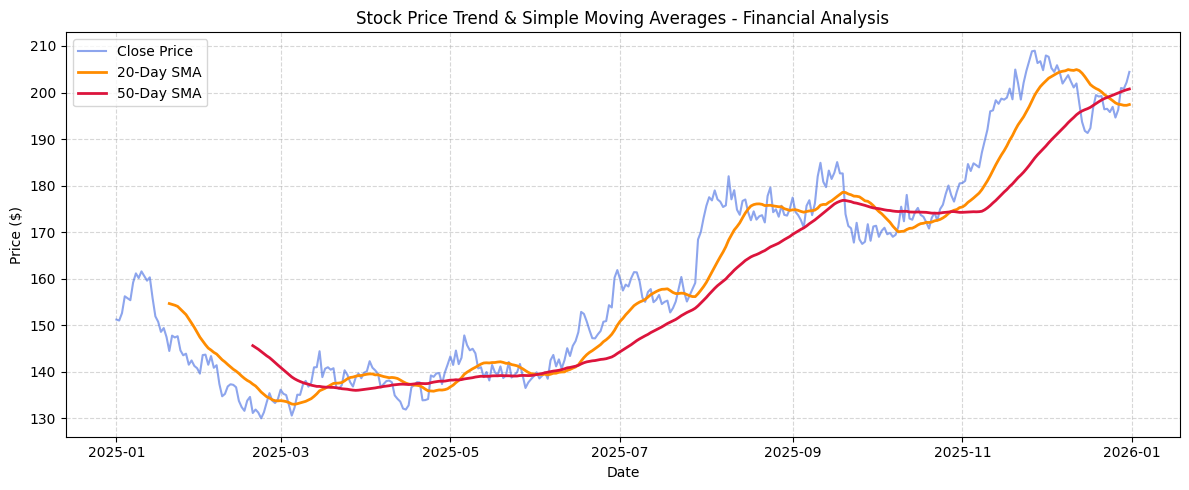

In [9]:
# 1. Stock Closing Price & Moving Averages Trend
plt.figure(figsize=(12, 5))
plt.plot(df_stock['Date'], df_stock['Close_Price'], color='royalblue', label='Close Price', alpha=0.6, linewidth=1.5)
plt.plot(df_stock['Date'], df_stock['MA_20'], color='darkorange', label='20-Day SMA', linewidth=2)
plt.plot(df_stock['Date'], df_stock['MA_50'], color='crimson', label='50-Day SMA', linewidth=2)

plt.title('Stock Price Trend & Simple Moving Averages - Financial Analysis')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

In [10]:
# Save visualization
plt.savefig('visualizations/project5_stock_trend.png')
plt.show()

<Figure size 640x480 with 0 Axes>

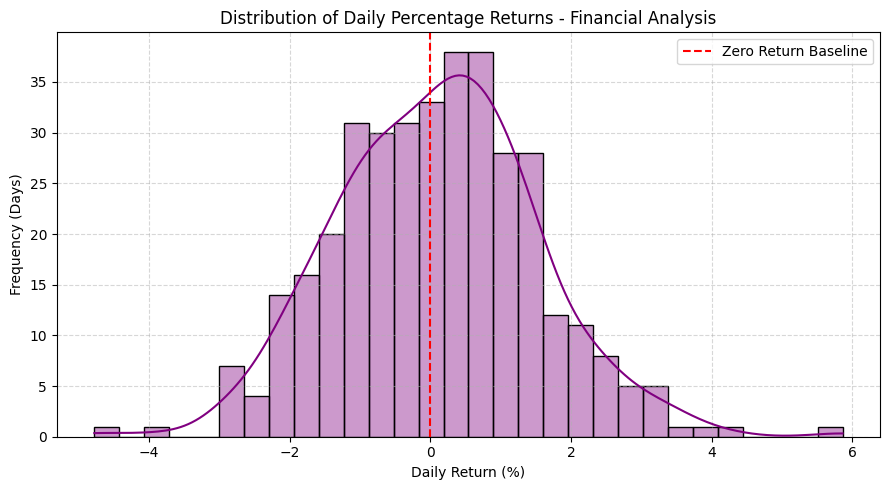

In [11]:
# 2. Daily Return Percentage Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df_stock['Daily_Return_Pct'], kde=True, color='purple', bins=30, edgecolor='black', alpha=0.4)

plt.title('Distribution of Daily Percentage Returns - Financial Analysis')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency (Days)')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Return Baseline')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

In [12]:
# Save visualization
plt.savefig('visualizations/project5_daily_returns_dist.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
# Extract month name for seasonal grouping
df_stock['Month'] = df_stock['Date'].dt.strftime('%b')

In [14]:
# Order months chronologically
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_vol = df_stock.groupby('Month')['Volume'].mean().reindex(months_order) / 1e6

C:\Users\ajasl\AppData\Local\Temp\ipykernel_19688\1736187185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_vol.index, y=monthly_vol.values, palette='Purples_r')


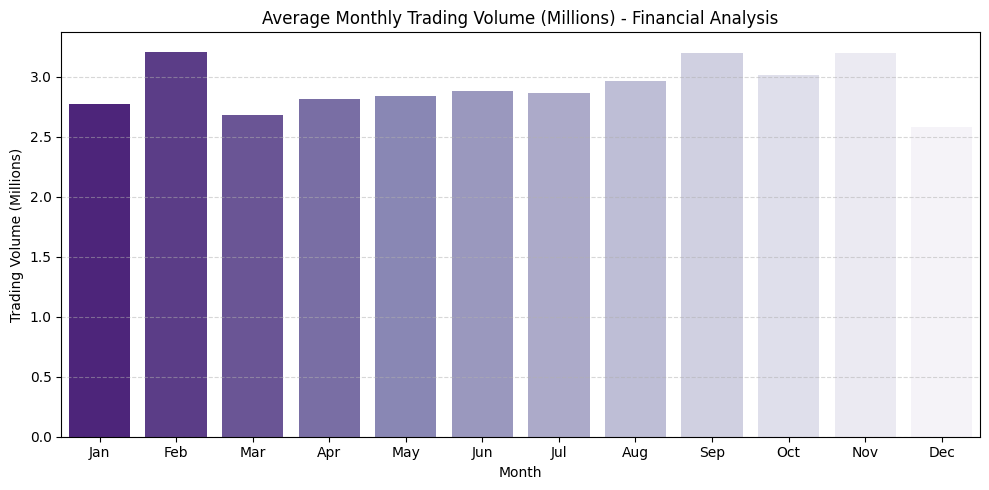

In [15]:
# 3. Monthly Average Trading Volume Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_vol.index, y=monthly_vol.values, palette='Purples_r')
plt.title('Average Monthly Trading Volume (Millions) - Financial Analysis')
plt.xlabel('Month')
plt.ylabel('Trading Volume (Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

In [16]:
# Save visualization
plt.savefig('visualizations/project5_monthly_volume.png')
plt.show()

<Figure size 640x480 with 0 Axes>